# Simple Linear Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/02-regression/01_simple_linear_regression.ipynb)

**Time**: ~20 minutes

## What You'll Learn
- Linear regression basics (y = mx + b)
- Fitting the line to data
- Making predictions
- Evaluating performance (R², MSE, MAE)

## Why This Matters

Linear regression is the **foundation** of ML.

**Example:** Predict house price from size
```
Size: 1000 sq ft → Price: $200k
Size: 2000 sq ft → Price: $350k
Size: 3000 sq ft → Price: ?  ← Predict!
```

**Simple formula:**
```
Price = 150 × Size + 50000
       (slope)    (intercept)
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

np.random.seed(42)
print("Simple Linear Regression: Fitting a Line to Data")

Simple Linear Regression: Fitting a Line to Data


---
## 1. Create Simple Dataset

In [2]:
# House size vs price
X = np.array([1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500]).reshape(-1, 1)
y = np.array([200, 250, 350, 410, 500, 600, 700, 750, 850, 900])

# Add some noise to make it realistic
y = y + np.random.normal(0, 50, len(y))

df = pd.DataFrame({'Size (sq ft)': X.flatten(), 'Price ($k)': y})
print("House Dataset:")
print(df.head())
print(f"\nShape: {df.shape}")

House Dataset:
   Size (sq ft)  Price ($k)
0          1000  224.835708
1          1500  243.086785
2          2000  382.384427
3          2500  486.151493
4          3000  488.292331

Shape: (10, 2)


---
## 2. Visualize Raw Data

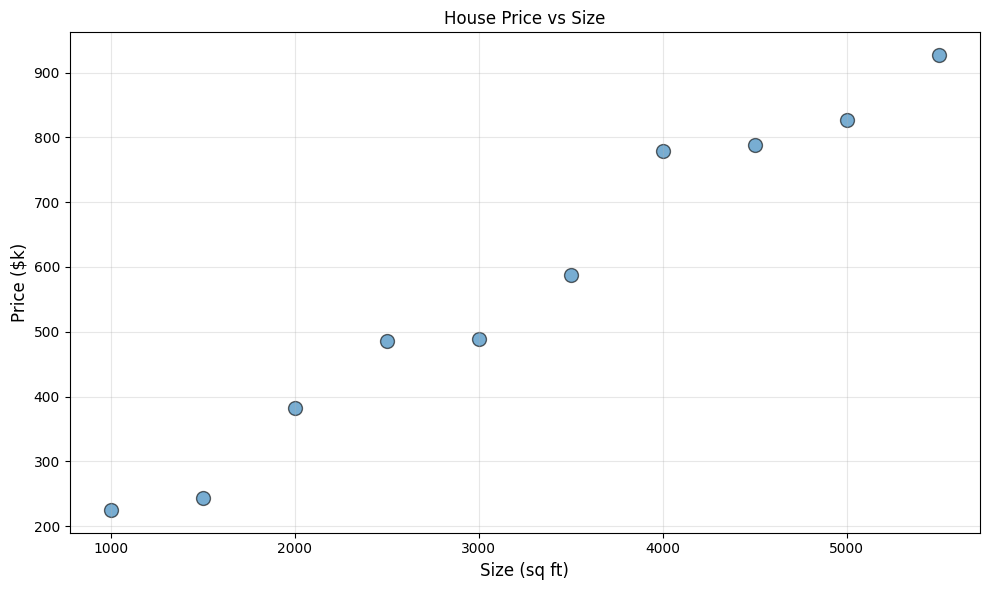

Clear positive relationship: Bigger house = Higher price


In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=100, alpha=0.6, edgecolors='black')
plt.xlabel('Size (sq ft)', fontsize=12)
plt.ylabel('Price ($k)', fontsize=12)
plt.title('House Price vs Size')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Clear positive relationship: Bigger house = Higher price")

---
## 3. Train Linear Regression

In [4]:
# Create and train model
model = LinearRegression()
model.fit(X, y)

# Extract slope and intercept
slope = model.coef_[0]
intercept = model.intercept_

print(f"Model Equation: y = {slope:.4f}x + {intercept:.2f}")
print(f"\nInterpretation:")
print(f"  - Slope: For every 1 sq ft → Price increases by ${slope:.2f}k")
print(f"  - Intercept: Base price (size=0) = ${intercept:.2f}k")
print(f"\nExample:")
print(f"  Size = 3000 sq ft")
example_price = slope * 3000 + intercept
print(f"  Predicted Price = {slope:.4f} × 3000 + {intercept:.2f} = ${example_price:.2f}k")

Model Equation: y = 0.1626x + 45.01

Interpretation:
  - Slope: For every 1 sq ft → Price increases by $0.16k
  - Intercept: Base price (size=0) = $45.01k

Example:
  Size = 3000 sq ft
  Predicted Price = 0.1626 × 3000 + 45.01 = $532.76k


---
## 4. Make Predictions

In [5]:
# Predict on training data
y_pred = model.predict(X)

# Predict on new data
new_sizes = np.array([[1200], [3500], [4800]])
predictions = model.predict(new_sizes)

print("Predictions for New Homes:")
for size, price in zip(new_sizes.flatten(), predictions):
    print(f"  Size: {size:5.0f} sq ft → Predicted Price: ${price:.2f}k")

Predictions for New Homes:
  Size:  1200 sq ft → Predicted Price: $240.11k
  Size:  3500 sq ft → Predicted Price: $614.05k
  Size:  4800 sq ft → Predicted Price: $825.41k


---
## 5. Visualize Fitted Line

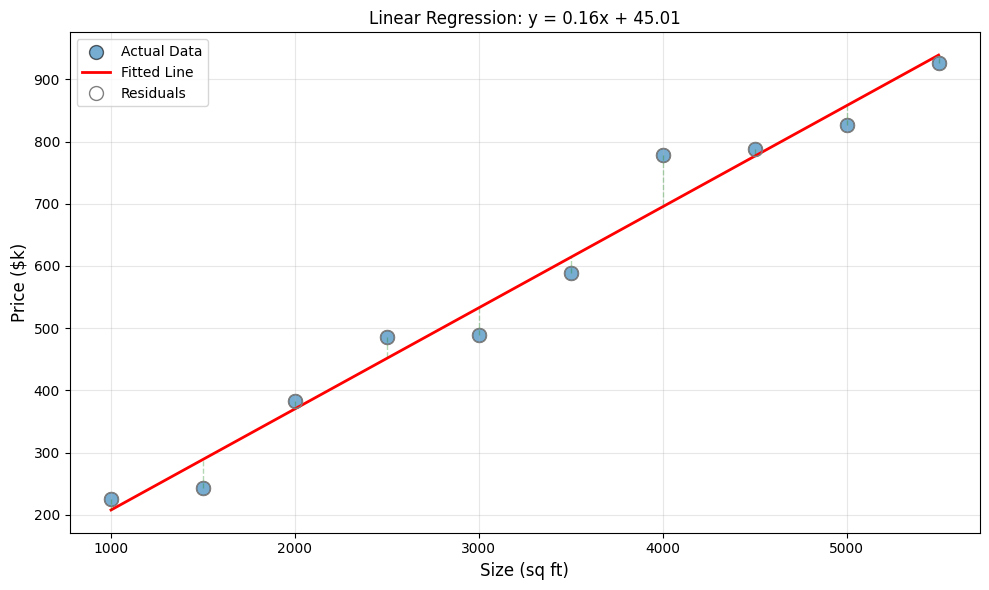

Green dashed lines = residuals (prediction errors)


In [6]:
plt.figure(figsize=(10, 6))

# Scatter plot
plt.scatter(X, y, s=100, alpha=0.6, label='Actual Data', edgecolors='black')

# Fitted line
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)
plt.plot(X_line, y_line, 'r-', linewidth=2, label='Fitted Line')

# Residuals
plt.plot(X, y, 'o', markerfacecolor='none', markersize=10, color='gray', label='Residuals')
for i in range(len(X)):
    plt.plot([X[i, 0], X[i, 0]], [y[i], y_pred[i]], 'g--', alpha=0.3, linewidth=1)

plt.xlabel('Size (sq ft)', fontsize=12)
plt.ylabel('Price ($k)', fontsize=12)
plt.title(f'Linear Regression: y = {slope:.2f}x + {intercept:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Green dashed lines = residuals (prediction errors)")

---
## 6. Evaluate Model Performance

In [7]:
# Calculate metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Model Performance Metrics:")
print(f"\nR² Score: {r2:.4f}")
print(f"  Interpretation: {r2*100:.2f}% of price variation explained by size")
print(f"  Range: [0, 1]. Higher = Better")

print(f"\nMSE (Mean Squared Error): {mse:.2f}")
print(f"  Average squared error (penalizes large errors)")

print(f"\nRMSE (Root MSE): {rmse:.2f}")
print(f"  Same units as y (price in $k)")
print(f"  Average prediction error: ±${rmse:.2f}k")

print(f"\nMAE (Mean Absolute Error): {mae:.2f}")
print(f"  Average absolute error: ±${mae:.2f}k")

Model Performance Metrics:

R² Score: 0.9738
  Interpretation: 97.38% of price variation explained by size
  Range: [0, 1]. Higher = Better

MSE (Mean Squared Error): 1464.94
  Average squared error (penalizes large errors)

RMSE (Root MSE): 38.27
  Same units as y (price in $k)
  Average prediction error: ±$38.27k

MAE (Mean Absolute Error): 31.90
  Average absolute error: ±$31.90k


---
## 7. Residuals Analysis

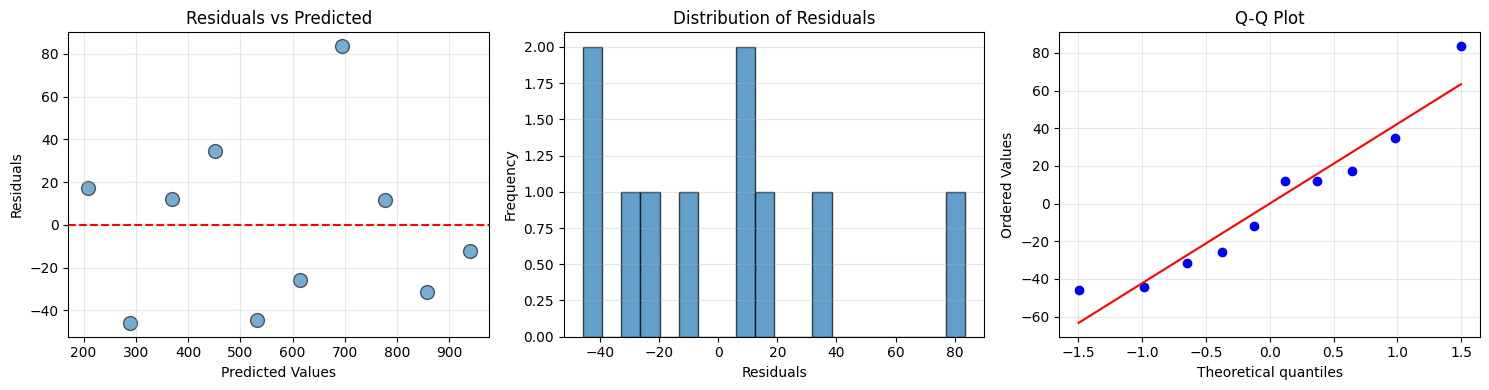

✅ Good residuals should be:
  - Centered at 0
  - Normally distributed
  - No pattern vs predicted values


In [8]:
# Calculate residuals
residuals = y - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs predicted
axes[0].scatter(y_pred, residuals, s=100, alpha=0.6, edgecolors='black')
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')
axes[0].grid(True, alpha=0.3)

# Histogram of residuals
axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')
axes[1].grid(True, alpha=0.3, axis='y')

# Q-Q plot
from scipy import stats as sp_stats
sp_stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Good residuals should be:")
print("  - Centered at 0")
print("  - Normally distributed")
print("  - No pattern vs predicted values")

---
## 8. Train-Test Evaluation

In [9]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
model_train = LinearRegression()
model_train.fit(X_train, y_train)

# Evaluate
train_r2 = model_train.score(X_train, y_train)
test_r2 = model_train.score(X_test, y_test)

print("Train-Test Split Evaluation:")
print(f"  Train R²: {train_r2:.4f}")
print(f"  Test R²:  {test_r2:.4f}")
print(f"\nDifference: {abs(train_r2 - test_r2):.4f}")

if abs(train_r2 - test_r2) < 0.05:
    print("✅ Good: Train and test scores similar (no overfitting)")
else:
    print("⚠️ Model may be overfitting")

Train-Test Split Evaluation:
  Train R²: 0.9757
  Test R²:  0.9567

Difference: 0.0190
✅ Good: Train and test scores similar (no overfitting)


---
## Key Takeaways

1. **Linear regression** = fit line to data
2. **Equation**: y = mx + b (slope + intercept)
3. **R²** = quality of fit (0-1, higher better)
4. **RMSE** = average error in original units
5. **Check residuals** for normality
6. **Compare train/test** scores to detect overfitting

Simple but powerful! Always start here before complex models.

---
## Your Turn

1. Load a dataset with one continuous feature
2. Train linear regression
3. Make predictions on new data
4. Evaluate R² and RMSE
5. Plot fitted line with residuals

In [10]:
# Your code here